# introduction

[介绍](https://www.kaggle.com/code/tomforbes/optiver-trading-at-the-close-introduction#Trading-At-The-Close)

## 介绍
### 一、背景：纳斯达克收盘博弈
收盘最后 10 分钟（15:50 - 16:00）是市场流动性最剧烈的时刻，采用集合竞价机制。    

订单规则：(15:50之前得是普通挂单)
- 限制：可委托，不支持撤单
- MOC (Market-On-Close)：不计价格，必须成交。主要由指数基金（如标普500指数基金，基金价格需要与指数相等）发起，是价格变动的主要冲击力。MOC往往在靠前时间点出现。MOC经常会暴力拉升价格已完成成交。
- LOC (Limit-On-Close)：有价格阈值。比如买单大于100块就不成交了.是市场的阻力位。不买入过高价格，不卖出过低价格。

撮合逻辑：交易所每 10 秒计算一次“虚拟撮合”，寻找能使成交量最大化的参考价 (Reference Price)。


### 二、价格发现
1. 近端价、远端价、参考价
交易所每10秒公布的三个价格，最终它们会收敛于收盘价。远端价和近端价从300秒开始公布。

| 价格维度 | 定义说明 | 数据特性 |
| :--- | :--- | :--- |
| **远端价 (Far Price)** | 仅考虑拍卖池内的订单（MOC/LOC）计算的成交价。如果是Nan就不能成交 | **高波动/高灵敏**：反映了最核心、最极端的供需缺口。若为 NaN，说明当前买卖盘完全无法匹配。 |
| **近端价 (Near Price)** | 考虑拍卖池订单 + 白天剩余的普通限价单计算的成交价。 | **稳定性**：由于加入了大量存量订单，它更接近最终真实的收盘平衡点。 |
| **参考价 (Reference Price)** | 经过保护机制修正的价格，通常介于近端与远端之间。 | **锚点**：它是交易所公布的官方基准，是所有 `Imbalance` 统计的起点。 |


2. wap
是成交量加权平均价格，所以总是介于ask和bid之间
$$
\frac{BidPrice * BidSize + AskPrice * AskSize}{BidSize + AskSize}
$$
- 溢价换取成交：当买方极度急切时，会在靠近卖价的位置堆积大量买单。此时 WAP 向上偏移，反映了买方宁愿支付高价也要成交的心理。

### 三、 供需平衡(动力)
供需动力是价格变动的原因。按照**Reference Price**撮合，imbalance代表无法撮合的量。
- imbalance_size：缺口绝对值。
- imbalance_buy_sell_flag：缺口方向。比如买单过多了，价格就将会上涨。
- 这预示了未来60秒价格移动方向和幅度。

### 四、预测相对收益率target
预测个股 60 秒后的收益率与大盘收益率的差值。即比大盘强还是弱。（能否跑赢大盘）    
$$
Target_t = (\frac{StockWap_{t+60}}{StockWap_t} - \frac{IndexWap_{t+60}}{IndexWap_t}) \times 1000
$$

为什么是相对收益率？而不是个股的收盘价？
- 大盘是受到宏观政策影响的，如美联储加息。不可预测。
- 相对收益率去除了大盘影响，更能反映个股真实表现。
- 这也能统一不同股票的量度。


In [1]:
import pandas as pd 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
import re
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error
from contextlib import contextmanager
import time
import os

gc.enable()
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
plt.rcParams['figure.figsize'] = (4,3) 
plt.rcParams['figure.dpi'] = 100

sns.set_theme(style="whitegrid", palette="Set1")


In [3]:
data = pd.read_csv('train.csv')

In [4]:
data.columns

Index(['stock_id', 'date_id', 'seconds_in_bucket', 'imbalance_size',
       'imbalance_buy_sell_flag', 'reference_price', 'matched_size',
       'far_price', 'near_price', 'bid_price', 'bid_size', 'ask_price',
       'ask_size', 'wap', 'target', 'time_id', 'row_id'],
      dtype='object')

In [6]:
def info_data(df):
    print(f'shape {df.shape}')
    n_stock =len(df['stock_id'].value_counts())
    print(f'stocks {n_stock}')
    n_days = len(df['date_id'].value_counts())
    print(f'days {n_days}')

In [7]:
info_data(data)

shape (5237980, 17)
stocks 200
days 481


In [8]:
def plot_stock(df, stock, date):

    fig, axes = plt.subplots(1,3, figsize=(15,5))
    plot_df = df[(df['stock_id'] ==stock) & (df['date_id'] == date) ]
    melted_data = plot_df.melt(
        id_vars = 'seconds_in_bucket',
        value_vars = ['far_price', 'near_price', 'reference_price','wap'],
        value_name = 'price_value',
        var_name = 'price_type'
    )
    # 左图：近端、远端价、参考价 收敛
    sns.lineplot(data=melted_data, x='seconds_in_bucket', y='price_value', hue='price_type', ax=axes[0])
    axes[0].set_title(f"Auction Prices (Stock {stock}, Day {date})")
    
    melted_data = plot_df.melt(
        id_vars = 'seconds_in_bucket',
        value_vars = ['bid_price', 'ask_price', 'wap'],
        var_name = 'Price_Type',
        value_name = 'Price_Value'
    )
    # 中图：订单本最优买卖价格
    sns.lineplot(data=melted_data, x='seconds_in_bucket', y='Price_Value', hue='Price_Type', ax=axes[1])
    axes[1].set_title(f"Market Liquidity (Stock {stock}, Day {date})")


    # 右图：imbalance
    axes[2].fill_between(plot_df['seconds_in_bucket'], plot_df['matched_size'], color='gray', alpha=0.3, label='Matched Size')
    axes[2].set_ylabel('Matched size')
    tax = axes[2].twinx()
    plot_df['signed_imb'] = plot_df['imbalance_size'] * plot_df['imbalance_buy_sell_flag']
    sns.lineplot(data=plot_df, x='seconds_in_bucket', y='signed_imb', ax=tax, label='Signed Imbalance')
    tax.set_ylabel('Signed Imbalance (Buy > 0, Sell < 0)', color='purple')
    axes[2].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[2].set_title(f"Imbalance Dynamics (Stock {stock}, Day {date})")

    plt.tight_layout()
    plt.show()

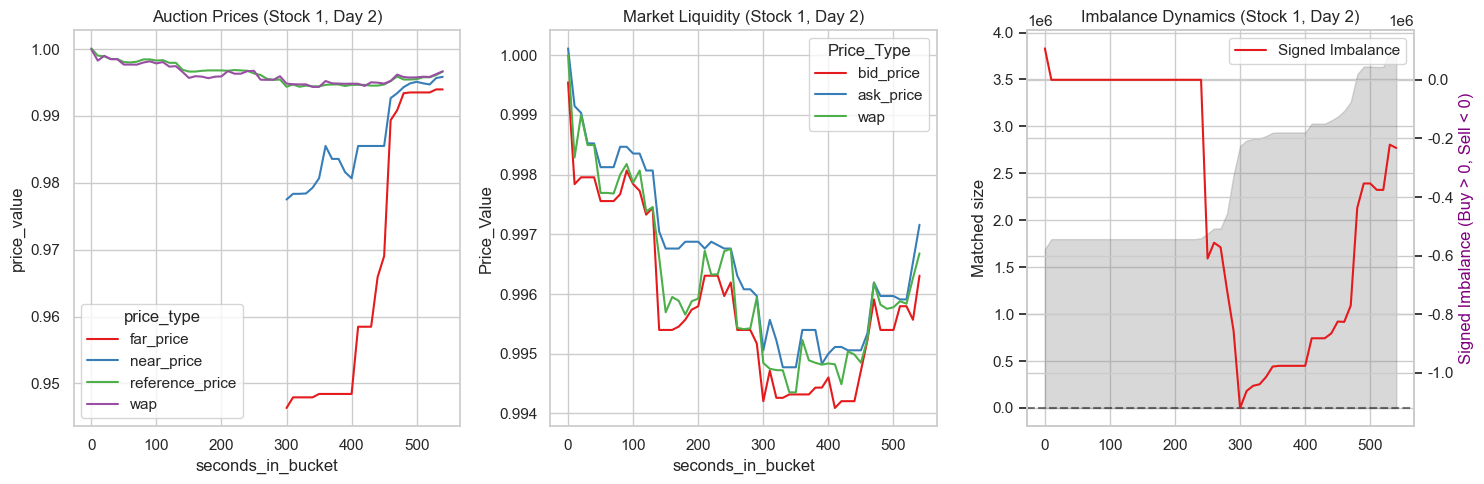

In [9]:
plot_stock(data, stock=1, date=2)

## metrics

MAE


## 字段说明
- 分布
- 统计：缺失、异常

In [11]:
def info_numeric_col(df, col):
    """ col列空间：统计、分布图、异常值图。
    """
    stat = pd.Series({
        'missing': df[col].isnull().sum(),
        'missing_percent': df[col].isnull().sum() / len(df[col]),
        'mean': df[col].mean(),
        'std':df[col].std(),
        'min': df[col].min(),
        '25%': df[col].quantile(0.25),
        'median': df[col].quantile(0.5),
        '75%': df[col].quantile(0.75),
        '99%': df[col].quantile(0.99), # 长尾
        'max': df[col].max(),
        'skewness': df[col].skew(), # 偏度
        'kurtosis': df[col].kurt() # 峰度
    })
    print(f"--- Statistics for {col} ---")    
    print(stat)
    fig, axes = plt.subplots(1,2, figsize=(8,4))
    
    sns.kdeplot(data=df, x=col, fill=True, ax=axes[0], color='red')
    axes[0].set_title(f'{col} distribution')

    sns.boxplot(data=df, x=col, ax= axes[1], color='green')
    axes[1].set_title(f'{col} outLiers')
    plt.tight_layout()
    plt.show()


In [12]:
data.isnull().sum()

stock_id                         0
date_id                          0
seconds_in_bucket                0
imbalance_size                 220
imbalance_buy_sell_flag          0
reference_price                220
matched_size                   220
far_price                  2894342
near_price                 2857180
bid_price                      220
bid_size                         0
ask_price                      220
ask_size                         0
wap                            220
target                          88
time_id                          0
row_id                           0
dtype: int64

## 特征构造
预测策略：
1. 价格发现：此时价格
2. 供需动力：imbalance
3. 流动性：放大价格。表明订单池子深度。高流动性意味实时成交量高，意味价格平稳，即不会因为一个订单价格剧烈波动。低流动性反之不平稳。这通过matched_size

## baseline

In [ ]:
data.isnull().sum()

In [30]:
y = data['target']
X = data[['reference_price','far_price', 'near_price', 'ask_price', 'bid_price', 'wap']]

In [46]:
data.shape

(5237980, 17)

In [45]:
np.isfinite(y).sum()

5237892

In [ ]:
X = X[np.isfinite(y)]
y = y[np.isfinite(y)]

In [48]:
X.shape

(5237892, 6)

In [49]:
model = LGBMRegressor()

In [50]:
model.fit(X=X, y=y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021072 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 5237892, number of used features: 6
[LightGBM] [Info] Start training from score -0.047561


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [53]:
y_pred = model.predict(X)

In [54]:
mean_absolute_error(y_pred, y)

6.320055859819497

In [ ]:
from public_timeseries_testing_util import make_env

In [ ]:
env = make_env()

In [ ]:
counter = 0
for (test, revealed_targets, sample_prediction) in env.iter_test():
    sample_prediction['target'] = model.predict(test.drop(columns=[ 'stock_id', 'date_id', 'seconds_in_bucket', 'row_id', 'time_id']))
    env.predict(sample_prediction)
    counter += 1